In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kienngx/nemotron-30b-competition-trainingdata-cot-labels/final_Nemotron_training_data.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 步骤 1: 数据加载与基础审查 (Loading & Inspection)
# ==========================================
print("--- 1. 正在加载数据 ---")
file_path = '/kaggle/input/datasets/kienngx/nemotron-30b-competition-trainingdata-cot-labels/final_Nemotron_training_data.csv'

# 读取CSV文件
df = pd.read_csv(file_path)

# 统一 id 格式为 string，防止 int/string 混用报错
df['id'] = df['id'].astype(str)

print(f"初始数据量: {len(df)} 条")

# 去重检查 (基于 id 列)
df = df.drop_duplicates(subset=['id'])
print(f"根据 ID 去重后的数据量: {len(df)} 条")

# 缺失值排查与剔除
df = df.dropna(subset=['prompt', 'answer', 'generated_cot', 'label'])
print(f"剔除缺失值后的有效数据量: {len(df)} 条\n")

--- 1. 正在加载数据 ---
初始数据量: 9500 条
根据 ID 去重后的数据量: 9500 条
剔除缺失值后的有效数据量: 9500 条



In [3]:
# ==========================================
# 步骤 2: 文本清洗 (Text Cleaning)
# ==========================================
print("--- 2. 正在进行文本清洗 ---")
def clean_text(text):
    if pd.isna(text):
        return text
    # 去除首尾多余的空格和换行符
    return str(text).strip()

# 对核心文本列应用清洗
columns_to_clean = ['prompt', 'answer', 'generated_cot', 'label']
for col in columns_to_clean:
    df[col] = df[col].apply(clean_text)

print("文本清洗完成。\n")

--- 2. 正在进行文本清洗 ---
文本清洗完成。



--- 3. 正在生成数据分布图表 ---


/tmp/ipykernel_17/2632100574.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=df, order=df['label'].value_counts().index, palette='viridis')


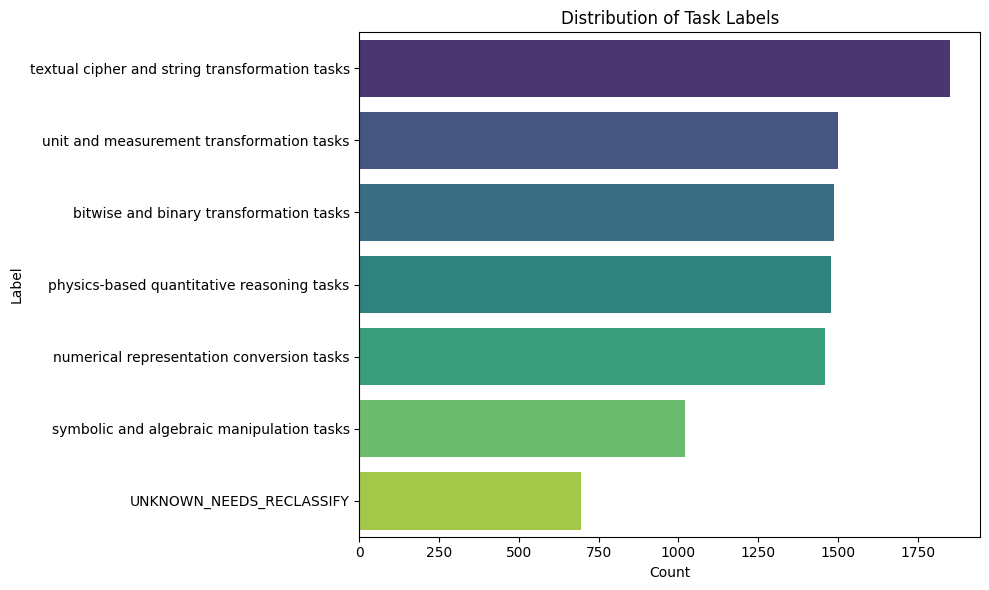

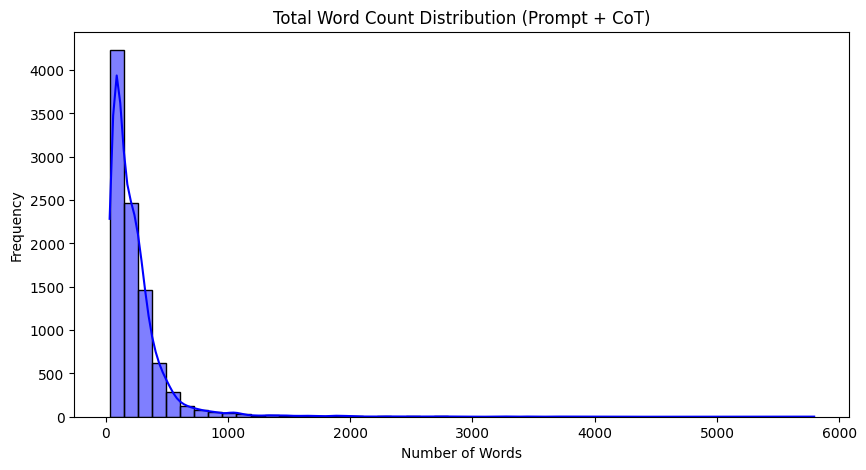

总词数超过 2000 词的样本数量: 30 条



In [4]:
# ==========================================
# 步骤 3: 数据分布与长度分析 (EDA)
# ==========================================
print("--- 3. 正在生成数据分布图表 ---")

# 3.1 绘制标签 (Label) 分布图
plt.figure(figsize=(10, 6))
sns.countplot(y='label', data=df, order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Task Labels')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show() # Kaggle 会直接显示图表

# 3.2 文本长度粗略统计 (使用词数替代 Token 数进行快速估算)
df['prompt_word_count'] = df['prompt'].apply(lambda x: len(x.split()))
df['cot_word_count'] = df['generated_cot'].apply(lambda x: len(x.split()))
df['total_word_count'] = df['prompt_word_count'] + df['cot_word_count']

plt.figure(figsize=(10, 5))
sns.histplot(df['total_word_count'], bins=50, kde=True, color='blue')
plt.title('Total Word Count Distribution (Prompt + CoT)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# 筛选超长文本（假设您目标模型的上下文窗口较小，例如这里查看 > 2000 词的样本）
long_texts = df[df['total_word_count'] > 2000]
print(f"总词数超过 2000 词的样本数量: {len(long_texts)} 条\n")

In [5]:
# ==========================================
# 步骤 4: 模版构建与保存 (Prompt Formatting)
# ==========================================
print("--- 4. 正在构建模型微调格式 (Instruction-Response) ---")

# 将 prompt 作为指令，将 思考过程(CoT) 和 最终答案(Answer) 拼接到 output 中
def format_for_finetuning(row):
    instruction = row['prompt']
    # 这里定义了模型输出的标准格式：先输出思考过程，再输出最终答案
    response = f"Thinking Process:\n{row['generated_cot']}\n\nFinal Answer:\n{row['answer']}"
    
    return pd.Series({
        'instruction': instruction, 
        'output': response, 
        'label': row['label']
    })

# 生成微调数据集
finetune_df = df.apply(format_for_finetuning, axis=1)

# 将处理好的数据保存到 Kaggle 的输出目录 (Working Directory)
# 保存为 jsonl 格式，这是大语言模型微调（如 Llama-Factory, HuggingFace Trainer）最常用的格式
output_path = '/kaggle/working/processed_finetune_data.jsonl'
finetune_df.to_json(output_path, orient='records', lines=True, force_ascii=False)

print(f"数据处理完毕！")
print(f"最终微调文件已保存至: {output_path}")
print(f"您可以在 Kaggle 右侧栏的 'Output' 文件夹中下载此文件。")

--- 4. 正在构建模型微调格式 (Instruction-Response) ---
数据处理完毕！
最终微调文件已保存至: /kaggle/working/processed_finetune_data.jsonl
您可以在 Kaggle 右侧栏的 'Output' 文件夹中下载此文件。
